In [12]:
from scipy import special as sy 
import numpy as np
import matplotlib.pyplot as plt

from point_mass import PointMass

from astropy import constants as const

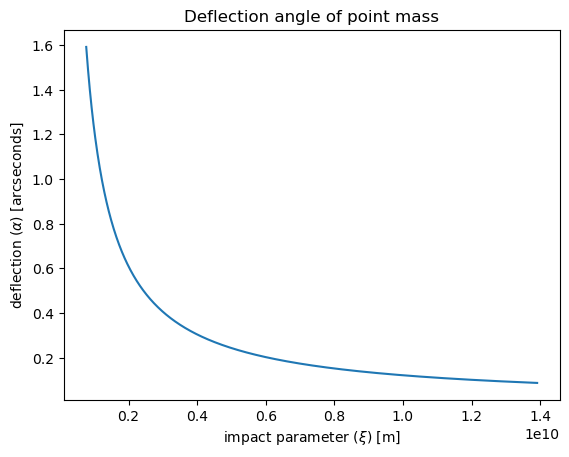

In [17]:
M = const.M_sun.value       # type: ignore
pm = PointMass(M)

xi = np.linspace(1.1, 20, 1000)*const.R_sun.value       # type: ignore
alpha = pm.get_deflection(xi, arcseconds=True)

plt.plot(xi,alpha)
plt.xlabel(r"impact parameter $(\xi)$ [m]")
plt.ylabel(r"deflection $(\alpha)$ [arcseconds]")

plt.title("Deflection angle of point mass")
plt.show()

Let's try it on an image of a galaxy.

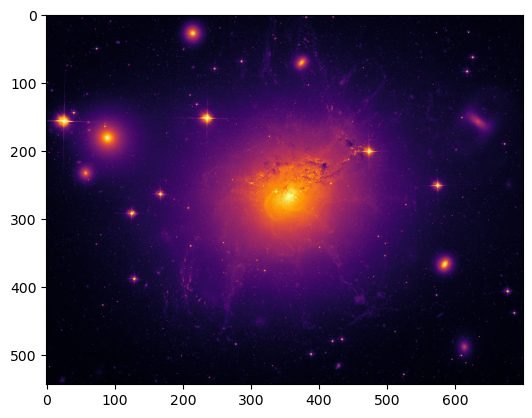

In [8]:
from PIL import Image

img = Image.open("galaxy.jpg").convert("L")
src = np.array(img) / 255.0  # normalized brightness

H, W = src.shape

# Output image
lensed = np.zeros_like(src)

plt.imshow(img, 'inferno')
plt.show()


In [9]:
# ------------------------------
# Physical / numerical setup
# ------------------------------
bh = point_bh(M=1.0)

# angular scale (arbitrary units)
theta_max = 50
x = np.linspace(-theta_max, theta_max, W)
y = np.linspace(-theta_max, theta_max, H)

X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2) + 1e-6  # avoid division by zero

# Simple distance scaling
D = 200.0  # adjust to tune distortion strength

# ------------------------------
# Ray tracing / mapping
# ------------------------------
for i in range(H):
    for j in range(W):
        r = R[i, j]
        theta_x = X[i, j]
        theta_y = Y[i, j]

        # deflection magnitude
        alpha = bh.defAngle(r)

        # unit direction of deflection
        ux = theta_x / r
        uy = theta_y / r

        # lens equation: source position
        beta_x = theta_x - alpha * ux / D
        beta_y = theta_y - alpha * uy / D

        # convert back to pixel coords
        lx = int((beta_x + theta_max) * W / (2*theta_max))
        ly = int((beta_y + theta_max) * H / (2*theta_max))

        # only if inside bounds
        if 0 <= ly < H and 0 <= lx < W:
            lensed[i, j] = src[ly, lx]


# ------------------------------
# Display results
# ------------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Original Galaxy")
plt.imshow(src, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Lensed Image (point BH)")
plt.imshow(lensed, cmap="gray")
plt.axis("off")

plt.show()


NameError: name 'point_bh' is not defined